In [6]:
!pip install osmnx

In [3]:
!pip install -r requirements.txt

     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     ------- -------------------------------- 3.1/15.8 MB 26.9 MB/s eta 0:00:01
     --------------------------------------- 15.8/15.8 MB 47.7 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + C:\Users\AP03542515\AppData\Local\anaconda3\python.exe C:\Users\AP03542515\AppData\Local\Temp\3\pip-install-sni__umu\numpy_eb3e0a945f0c4c9696eb24aa60be9c42\vendored-meson\meson\meson.py setup C:\Users\AP03542515\AppData\Local\Temp\3\pip-install-sni__umu\numpy_eb3e0a945f0c4c9696eb24aa60be9c42 C:\Users\AP03542515\AppData\Local\Temp\3\pip-install-sni__umu\numpy_eb3e0a945f0c4c9696eb24aa60be9c42\.mesonpy-3sgjmn5u -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\AP03542515\AppData\Local\Temp\3\pip-install-sni__umu\numpy_eb3e0a945f0c4c9696eb24aa60be9c42\.mesonpy-3sgjmn5u\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\AP03542515\AppData\Local\Temp\3\pip-install-sni__umu\numpy_eb3e0a945f0c4c9696eb24aa60be9c42
      Build dir: C:\Users\AP03542515\AppDa

In [7]:
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx 

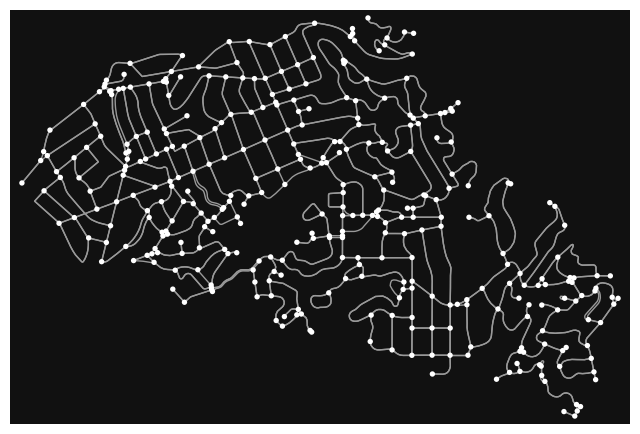

In [8]:
# download/model a street network for some city then visualize it
place = "Piedmont, California, USA"
G = ox.graph.graph_from_place(place, network_type="drive")
fig, ax = ox.plot.plot_graph(G)

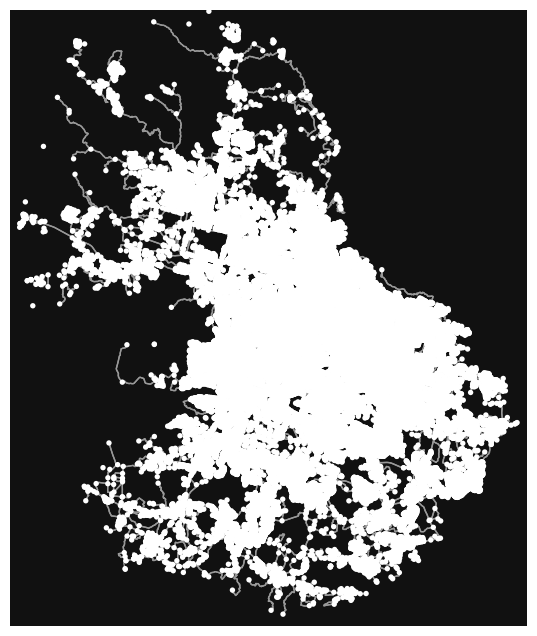

In [ ]:
places = [
    "Guadalajara, Jalisco, Mexico",
    "Zapopan, Jalisco, Mexico",
    "San Pedro Tlaquepaque, Jalisco, Mexico",
    "Tonalá, Jalisco, Mexico",
    "Tlajomulco de Zúñiga, Jalisco, Mexico",
    "El Salto, Jalisco, Mexico"
]

G = ox.graph_from_place(places, network_type="drive", retain_all=True)

fig, ax = ox.plot_graph(G)

<Axes: >

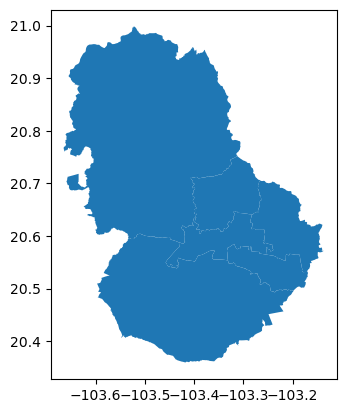

In [62]:
gdf = ox.geocode_to_gdf(places)
gdf.plot()


In [55]:
nodes, edges = ox.graph_to_gdfs(G)

In [56]:
nodes = nodes.reset_index()
nodes

,osmid,y,x,street_count,highway,junction,railway,ref,geometry
0,28751344,20.711533,-103.306309,3,NaN,NaN,NaN,NaN,POINT (-103.30631 20.71153)
1,28753224,20.700650,-103.316645,3,NaN,NaN,NaN,NaN,POINT (-103.31665 20.70065)
2,28757751,20.708531,-103.307371,3,NaN,NaN,NaN,NaN,POINT (-103.30737 20.70853)
3,28757777,20.710096,-103.306817,4,crossing,NaN,NaN,NaN,POINT (-103.30682 20.7101)
4,28768905,20.696546,-103.305728,3,NaN,NaN,NaN,NaN,POINT (-103.30573 20.69655)
...,...,...,...,...,...,...,...,...,...
118095,13640379871,20.733964,-103.417583,1,NaN,NaN,NaN,NaN,POINT (-103.41758 20.73396)
118096,13653694433,20.591899,-103.404321,1,NaN,NaN,NaN,NaN,POINT (-103.40432 20.5919)
118097,13658896180,20.736149,-103.417884,1,NaN,NaN,NaN,NaN,POINT (-103.41788 20.73615)
118098,13659280148,20.737977,-103.412693,3,NaN,NaN,NaN,NaN,POINT (-103.41269 20.73798)


In [57]:
nodes['node_id'] = nodes.index + 1

In [58]:
nodes

,osmid,y,x,street_count,highway,junction,railway,ref,geometry,node_id
0,28751344,20.711533,-103.306309,3,NaN,NaN,NaN,NaN,POINT (-103.30631 20.71153),1
1,28753224,20.700650,-103.316645,3,NaN,NaN,NaN,NaN,POINT (-103.31665 20.70065),2
2,28757751,20.708531,-103.307371,3,NaN,NaN,NaN,NaN,POINT (-103.30737 20.70853),3
3,28757777,20.710096,-103.306817,4,crossing,NaN,NaN,NaN,POINT (-103.30682 20.7101),4
4,28768905,20.696546,-103.305728,3,NaN,NaN,NaN,NaN,POINT (-103.30573 20.69655),5
...,...,...,...,...,...,...,...,...,...,...
118095,13640379871,20.733964,-103.417583,1,NaN,NaN,NaN,NaN,POINT (-103.41758 20.73396),118096
118096,13653694433,20.591899,-103.404321,1,NaN,NaN,NaN,NaN,POINT (-103.40432 20.5919),118097
118097,13658896180,20.736149,-103.417884,1,NaN,NaN,NaN,NaN,POINT (-103.41788 20.73615),118098
118098,13659280148,20.737977,-103.412693,3,NaN,NaN,NaN,NaN,POINT (-103.41269 20.73798),118099


In [59]:
edges = edges.reset_index()
edges

,u,v,key,osmid,highway,junction,lanes,oneway,reversed,length,geometry,name,maxspeed,tunnel,ref,bridge,access,width
0,28751344,1610958191,0,147983303,secondary,roundabout,2,True,False,22.824592,"LINESTRING (-103.30631 20.71153, -103.30624 20...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,28751344,28757777,0,824657718,tertiary,NaN,2,False,False,168.215321,"LINESTRING (-103.30631 20.71153, -103.30634 20...",Calle San Ignacio,NaN,NaN,NaN,NaN,NaN,NaN
2,28753224,1601906810,0,8148957,residential,NaN,2,False,False,47.170569,"LINESTRING (-103.31665 20.70065, -103.31625 20...",Calle Nudo de Cempoaltépetl,NaN,NaN,NaN,NaN,NaN,NaN
3,28753224,1601906764,0,8148957,residential,NaN,2,False,True,48.083655,"LINESTRING (-103.31665 20.70065, -103.31705 20...",Calle Nudo de Cempoaltépetl,NaN,NaN,NaN,NaN,NaN,NaN
4,28757751,6133633659,0,105072369,tertiary,NaN,4,False,False,129.726639,"LINESTRING (-103.30737 20.70853, -103.30776 20...",Calle San Ignacio,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284444,13658896180,7700606273,0,824690971,living_street,NaN,NaN,True,False,24.215563,"LINESTRING (-103.41788 20.73615, -103.41785 20...",Privada Santa María,NaN,NaN,NaN,NaN,NaN,NaN
284445,13659280148,1880262978,0,894457796,residential,NaN,NaN,False,True,4.532235,"LINESTRING (-103.41269 20.73798, -103.41268 20...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
284446,13659280148,13659280149,0,1490274506,residential,NaN,NaN,False,False,27.053998,"LINESTRING (-103.41269 20.73798, -103.41244 20...",Sandías,NaN,NaN,NaN,NaN,NaN,NaN
284447,13659280148,8313709490,0,894457796,residential,NaN,NaN,False,False,38.692850,"LINESTRING (-103.41269 20.73798, -103.41271 20...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
nodes.to_file("nodes_v2.shp")

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_66404\3734023148.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes.to_file("nodes_v2.shp")
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


In [43]:
id_map = dict(zip(nodes["osmid"], nodes["node_id"]))
id_map

{28751344: 1,
 28753224: 2,
 28757751: 3,
 28757777: 4,
 28768905: 5,
 28769466: 6,
 28771230: 7,
 28772094: 8,
 28772132: 9,
 28774831: 10,
 28774889: 11,
 28775949: 12,
 28776032: 13,
 28776223: 14,
 28776246: 15,
 28776279: 16,
 28777191: 17,
 28777954: 18,
 28781279: 19,
 28781298: 20,
 28781333: 21,
 28781359: 22,
 28781433: 23,
 28781516: 24,
 28781517: 25,
 28781518: 26,
 28781520: 27,
 28781522: 28,
 28781523: 29,
 28781524: 30,
 28781529: 31,
 28781530: 32,
 28791285: 33,
 28791315: 34,
 28791320: 35,
 28791354: 36,
 28791359: 37,
 28791518: 38,
 28791819: 39,
 130153606: 40,
 130153676: 41,
 130153753: 42,
 130153815: 43,
 130154244: 44,
 251530643: 45,
 251530655: 46,
 251538467: 47,
 251538474: 48,
 267537966: 49,
 267537978: 50,
 267537985: 51,
 267537992: 52,
 267538810: 53,
 267538815: 54,
 273145566: 55,
 273146454: 56,
 273146456: 57,
 273146461: 58,
 273146466: 59,
 273152670: 60,
 273152800: 61,
 273152806: 62,
 273153681: 63,
 273154015: 64,
 273157805: 65,
 2731586

In [48]:
edges["u"] = edges["u"].map(id_map)
edges["v"] = edges["v"].map(id_map)
edges

,u,v,key,osmid,highway,junction,lanes,oneway,reversed,length,geometry,name,maxspeed,tunnel,ref,bridge,access,width
0,1,17475,0,147983303,secondary,roundabout,2,True,False,22.824592,"LINESTRING (-103.30631 20.71153, -103.30624 20...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,4,0,824657718,tertiary,NaN,2,False,False,168.215321,"LINESTRING (-103.30631 20.71153, -103.30634 20...",Calle San Ignacio,NaN,NaN,NaN,NaN,NaN,NaN
2,2,16680,0,8148957,residential,NaN,2,False,False,47.170569,"LINESTRING (-103.31665 20.70065, -103.31625 20...",Calle Nudo de Cempoaltépetl,NaN,NaN,NaN,NaN,NaN,NaN
3,2,16656,0,8148957,residential,NaN,2,False,True,48.083655,"LINESTRING (-103.31665 20.70065, -103.31705 20...",Calle Nudo de Cempoaltépetl,NaN,NaN,NaN,NaN,NaN,NaN
4,3,78215,0,105072369,tertiary,NaN,4,False,False,129.726639,"LINESTRING (-103.30737 20.70853, -103.30776 20...",Calle San Ignacio,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263274,110505,92701,0,824690971,living_street,NaN,NaN,True,False,24.215563,"LINESTRING (-103.41788 20.73615, -103.41785 20...",Privada Santa María,NaN,NaN,NaN,NaN,NaN,NaN
263275,110506,52302,0,894457796,residential,NaN,NaN,False,True,4.532235,"LINESTRING (-103.41269 20.73798, -103.41268 20...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
263276,110506,110507,0,1490274506,residential,NaN,NaN,False,False,27.053998,"LINESTRING (-103.41269 20.73798, -103.41244 20...",Sandías,NaN,NaN,NaN,NaN,NaN,NaN
263277,110506,96398,0,894457796,residential,NaN,NaN,False,False,38.692850,"LINESTRING (-103.41269 20.73798, -103.41271 20...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
edges["u"].isna().sum()
edges["v"].isna().sum()

np.int64(0)

In [50]:
edges.to_file("edges.shp")

c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value '[1135990924, 1135990929, 1417643156, 1417643157, 1135990934, 1290072087, 1290072089, 1290072090, 1135990907, 1135990868, 1135990875, 1386358748, 1135990876, 1386358749, 1135990881, 1249584354, 1135990883, 1249584356, 1135990885, 1249584358, 1249584359, 1249584360, 1249584361, 1249584362, 1249584363, 1249584357, 1135990900, 1135990903, 1392865274, 1392865275]' of field osmid has been truncated to 254 characters.  This warning will not be emitted any more for that layer.
  ogr_write(
